Numeros generados:  [0.5117250160285028, 0.2423719552922925, 0.9057586805085529, 0.8065835860205927, 0.6579974419868293, 0.36856967748158564, 0.05638503105806758, 0.2498746086269934, 0.5626301150516418, 0.625541946640383]


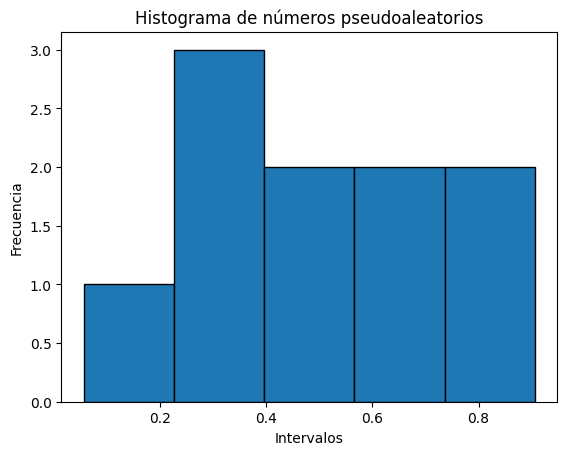

In [16]:
#-------------------------
# IMPORTANDO LAS LIBRERIAS NECESARIAS
#-------------------------
#random: lo utilizaremos para generar numeros pseudoaleatorios
#scipy.stats.chi2: para obtener el valor crítico de la distribución Chi-cuadrado
import random as rd
from scipy.stats import chi2 
import matplotlib.pyplot as plt

#-----0 IMPLICACIONES GENERAL DEL EXPERIMENTO----#
n=10 #cantidad de numeros a generar
k=5 #cantidad de intervalos a utilizar


#-----1. GENERACION DE NUMEROS PSEUDOALEATORIOS-----#
#creamos un generador utilizando la libreria random
rng = rd.Random() 

#se generan los n numeros aleatorios en el intervalo (0,1)
numeros = [rd.random() for _ in range(n)] 

#mostramos los numeros generados
print("Numeros generados: ",numeros)

# El histograma permite visualizar cómo se distribuyen los números
# dentro del intervalo (0,1)

plt.hist(numeros, bins=5, edgecolor='black')

plt.title("Histograma de números pseudoaleatorios")
plt.xlabel("Intervalos")
plt.ylabel("Frecuencia")

plt.show()

In [4]:
#-----2. APLICACION DEL TEST CHI-CUADRADO----#
# Intervalos utilizados:
# I1 (0.0 - 0.2)
# I2 (0.2 - 0.4)
# I3 (0.4 - 0.6)
# I4 (0.6 - 0.8)
# I5 (0.8 - 1.0)
#-----2.1 CALCULO DE FRECUENCIAS OBSERVADAS----#
#lista para contar los numeros dentro de los intervalos
I = [0]*5

#Clasificar a cual intervalo pertenece cada numero generado
for num in numeros:
    if 0.0 <= num < 0.2:
        I[0] += 1
    elif 0.2 <= num < 0.4:
        I[1] += 1
    elif 0.4 <= num < 0.6:
        I[2] += 1
    elif 0.6 <= num < 0.8:
        I[3] += 1
    elif 0.8 <= num <= 1.0: 
        I[4] += 1
        
#Mostrar las frecuencias observadas
print(f"Frecuencias observadas: {I[0]}, {I[1]}, {I[2]}, {I[3]}, {I[4]}")


#-----2.2CALCULO DE FRECUENCIAS ESPERADAS----#
#si los numeros generados siguen una distribucion uniforme
#cada intervalo debera contener aproximadamente n/k valores
Ei = n/k #cantidad num/intervalos

print(f"Frecuencias Esperada: {Ei}")

Frecuencias observadas: 2, 0, 3, 3, 2
Frecuencias Esperada: 2.0


In [5]:
#-----2.3 CALCULO ESTADISTICO CHI-CUADRADO---#
#aplicamos la formula 
# χ² = Σ (Oi - Ei)² / Ei
#
# donde:
# Oi = frecuencia observada
# Ei = frecuencia esperada

Xcuadrado=0
for fObservada in I:
    Xcuadrado+= ((fObservada-Ei)**2)/(Ei)
print( f"Valor calculado del test: {Xcuadrado}")

Valor calculado del test: 3.0


In [6]:
#----- 2.4 DEFINICION DE NIVEL DE SIGNIFICACIA Y GRADOS DE LIBERTAD----#
# Nivel de significancia (probabilidad de error tipo I)
a=0.05 #5% error permitido

# Grados de libertad
# Para el test Chi-cuadrado en uniformidad:
# gl = k - 1
gl= k-1   # intervalos-1


In [7]:
#----2.5 OBTENER VALOR CRITICO DE LA DISTRIBUCION CHI CUADRADO----#
#En lugar de usar una tabla estadística manual,
# Python calcula el valor crítico usando la función ppf

valorCritico = chi2.ppf(1 - a, gl)

print("Valor crítico:", valorCritico)

Valor crítico: 9.487729036781154


In [8]:
#---- 2.6 DECISIÓN DEL TEST----#
# Se compara el valor calculado con el valor crítico
# Si χ² calculado < χ² crítico -> no se rechaza Hipotesis de uniformidad

if Xcuadrado < valorCritico:
    print ("No se rechaza la hipotesis de uniformidad")
else:
    prinf("Los números no son lo suficientemente aleatorios.")

No se rechaza la hipotesis de uniformidad


Pares generados:
[(0.7445568116857826, 0.8513512579124919), (0.8513512579124919, 0.6436968201735812), (0.6436968201735812, 0.43927701872048475), (0.43927701872048475, 0.4490173632978036), (0.4490173632978036, 0.428379711546206), (0.428379711546206, 0.12345407128115737), (0.12345407128115737, 0.011654265816200882), (0.011654265816200882, 0.6543240772039777), (0.6543240772039777, 0.8369864790889214)]


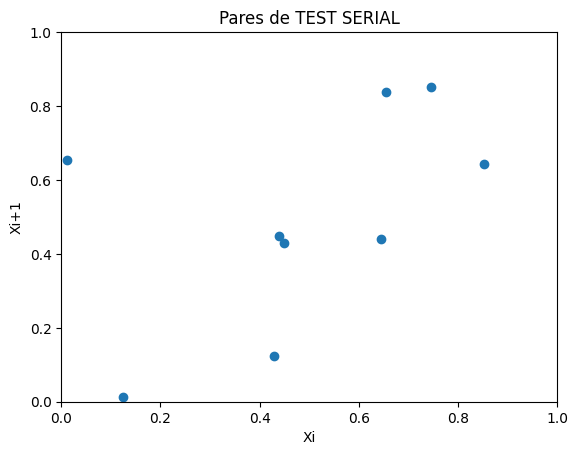

In [15]:
#---------------------------------------------------------------
#-------------3. APLICACION DEL TEST SERIAL---------------------
#Aqui tomaremos los numeros en pares y no individualmente 
pares = []

for i in range(len(numeros) - 1):
    pares.append((numeros[i], numeros[i+1]))

print("Pares generados:")
print(pares)

#ploteo de los pares generados 
# separar coordenadas
x_vals = []
y_vals = []

for x, y in pares:
    x_vals.append(x)
    y_vals.append(y)

# scatter plot
plt.scatter(x_vals, y_vals)

plt.title("Pares de TEST SERIAL")
plt.xlabel("Xi")
plt.ylabel("Xi+1")

plt.xlim(0,1)
plt.ylim(0,1)

plt.show()

In [10]:
#----3.1 DEFINIR INTERVALOS -----#
#usaremos 2 tanto para X y para Y  0.0-0.5 y 0.5-1.0
# matriz 2x2
matriz = [[0,0], # (0.0-0.5, 0.0-0.5)  (0.0-0.5, 0.5-1.0)
          [0,0]]#  (0.5-1.0, 0.0-0.5)  (0.5-1.0, 0.5-1.0)

#-----3.2 CLASIFICAR A QUE INTERVALO PERTENECEN LOS PARES-----#
for x, y in pares:

    # clasificar x
    if x < 0.5:
        i = 0
    else:
        i = 1

    # clasificar y
    if y < 0.5:
        j = 0
    else:
        j = 1

    matriz[i][j] += 1

print("Matriz de frecuencias observadas:")
for fila in matriz:
    print(fila)

Matriz de frecuencias observadas:
[4, 1]
[1, 3]


In [11]:
#----3.3 CALCULAR LA FRECUENCIA ESPERADA ----#
n_pares = len(pares)

Ei = n_pares / 4  # 4 porque son las celdas que tiene la matriz

print("Frecuencia esperada:", Ei)

Frecuencia esperada: 2.25


In [12]:
#----3.4 CALCULAR CHI-CUADRADO DEL TEST SERIAL-----#

X_serial = 0

for fila in matriz:
    for frecuencia in fila:
        X_serial += ((frecuencia - Ei)**2) / Ei

print("Chi-cuadrado serial:", X_serial)

Chi-cuadrado serial: 3.0


In [13]:
#----3.5 GRADOS DE LIBERTAD  y CALCULO DEL VALOR CRITICO-----#

gl = 4 - 1

alpha = 0.05


# valor crítico
valorCritico = chi2.ppf(1 - alpha, gl)

print("Valor crítico:", valorCritico)


# decisión
if X_serial < valorCritico:
    print("No se rechaza la independencia.")
else:
    print("Los números no parecen independientes.")

Valor crítico: 7.814727903251179
No se rechaza la independencia.
